In [1]:
from pathlib import Path
import json, yaml, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib.ticker as mtick
import seaborn as sns



In [2]:
df_rsna = pd.read_csv("data/embed_mendeley_with_aug.csv")
df_mendeley = pd.read_csv("data/embed_rsna_with_aug.csv")

df_rsna = df_rsna[df_rsna['aug_k'] == 0]
df_mendeley = df_mendeley[df_mendeley['aug_k'] == 0]
n_samples_rsna = df_rsna.shape[0]
n_samples_mendeley = df_mendeley.shape[0]

In [3]:
n_samples_rsna, n_samples_mendeley

(18679, 19220)

In [3]:
def run_folder_to_df_with_clients(run_folder: Path, prefer_meta: bool = True):
    """
    Returns:
      run_df:    per-round DataFrame with run-level metrics (chosen macro_f1), timings, aggregated picks, + YAML params
      client_df: per-round, per-client DataFrame with RF/META metrics (if present) and client-level picked counts
    """
    run_folder = Path(run_folder)

    # ----- pick YAML -----
    yaml_paths = sorted(run_folder.glob("*.yaml"))
    if not yaml_paths:
        raise FileNotFoundError(f"No YAML found in {run_folder}")
    yaml_path = next((p for p in yaml_paths if p.name.startswith("derived_")), yaml_paths[0])

    # ----- pick JSONL -----
    jsonl_paths = list(run_folder.glob("*.jsonl"))
    if not jsonl_paths:
        raise FileNotFoundError(f"No JSONL found in {run_folder}")
    jsonl_path = max(jsonl_paths, key=lambda p: p.stat().st_size)

    # ----- load YAML -----
    with open(yaml_path, "r", encoding="utf-8") as f:
        cfg = yaml.safe_load(f) or {}

    def g(node, path, default=None):
        cur = node
        for k in path.split("."):
            if not isinstance(cur, dict): return default
            cur = cur.get(k)
        return cur if cur is not None else default

    params = {
        "seed_k":            g(cfg, "seed_k"),
        "rounds":            g(cfg, "rounds"),
        "al_method_cfg":     g(cfg, "al.method"),
        "batch_B":           g(cfg, "al.batch_B"),
        "per_class_min":     g(cfg, "al.per_class_min"),
        "aug_K":             g(cfg, "augment.train_n_per_sample"),
        "meta_mode":         g(cfg, "meta.aug_mode"),
        "tta_n":             g(cfg, "meta.tta_n"),
        "meta_lambda":       g(cfg, "meta.lambda"),
        "rf_n_estimators":   g(cfg, "rf.n_estimators"),
        "rf_max_features":   g(cfg, "rf.max_features"),
        "seeding_method":    g(cfg, "seeding.method"),
    }
    seed_k  = int(params.get("seed_k") or 0)
    batch_B = int(params.get("batch_B") or 1)

    # ----- read JSONL -----
    records = []
    with open(jsonl_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line: 
                continue
            try:
                records.append(json.loads(line))
            except json.JSONDecodeError:
                pass
    if not records:
        raise ValueError(f"No valid JSON objects in {jsonl_path}")

    # ----- helpers for metric extraction -----
    def _get_metric(d, keys=("macro_f1","f1_macro")):
        """Return the first present metric from keys; else None."""
        if not isinstance(d, dict): 
            return None
        for k in keys:
            if k in d and d[k] is not None:
                return d[k]
        return None

    def _get_opt(d, key):
        return (d.get(key) if isinstance(d, dict) else None)

    # ----- build per-round run-level and per-client rows -----
    run_rows = []
    client_rows = []

    for i, rec in enumerate(records[:-1], start=1):
        labels = seed_k + i * batch_B

        avg = rec.get("avg", {}) or {}
        rf  = avg.get("rf", {}) or {}
        me  = avg.get("meta", {}) or {}

        rf_macro   = _get_metric(rf)
        me_macro   = _get_metric(me)
        macro_f1   = me_macro if (prefer_meta and me_macro is not None) else (rf_macro if rf_macro is not None else me_macro)

        # Optional metrics (None if not logged)
        rf_bal     = _get_opt(rf, "balanced_acc")
        me_bal     = _get_opt(me, "balanced_acc")
        rf_auc     = _get_opt(rf, "ovr_auc")
        me_auc     = _get_opt(me, "ovr_auc")

        # timings
        t = rec.get("timing_sec", {}) or {}
        t_train = float(t.get("train", 0.0))
        t_meta  = float(t.get("meta_refresh", 0.0))  # your logs use meta_refresh
        t_eval  = float(t.get("eval", 0.0))
        t_acq   = float(t.get("acquire", 0.0))

        # aggregate picks across clients
        picked_per_class_agg = {}
        clients = rec.get("clients", {}) or {}
        if isinstance(clients, dict):
            for cname, cinfo in clients.items():
                # Client-level metrics (if present)
                
                crf  = cinfo.get("rf", {}) or {}
                cme  = cinfo.get("meta", {}) or {}
                crf_macro = _get_metric(crf)
                cme_macro = _get_metric(cme)

                client_rows.append({
                    "round": i,
                    "labels": labels,
                    "client": cname,
                    "rf_macro_f1": crf_macro,
                    "meta_macro_f1": cme_macro,
                    "rf_bal_acc": _get_opt(crf, "balanced_acc"),
                    "meta_bal_acc": _get_opt(cme, "balanced_acc"),
                    "rf_auc_ovr": _get_opt(crf, "ovr_auc"),
                    "meta_auc_ovr": _get_opt(cme, "ovr_auc"),
                    "picked_per_class": (cinfo or {}).get("picked_per_class"),
                    "picked_total": (sum((cinfo or {}).get("picked_per_class", {}).values())
                                     if isinstance((cinfo or {}).get("picked_per_class"), dict) else 0),
                    "al_method_log": rec.get("al_method"),
                    **params,
                    "run_id": run_folder.name,
                    "path": str(run_folder),
                })

                # aggregate picks
                ppc = (cinfo or {}).get("picked_per_class")
                if isinstance(ppc, dict):
                    for cls, cnt in ppc.items():
                        try:
                            picked_per_class_agg[cls] = picked_per_class_agg.get(cls, 0) + int(cnt)
                        except Exception:
                            pass

        run_rows.append({
            "round": i,
            "labels": labels,
            "macro_f1": macro_f1,
            "rf_macro_f1": rf_macro,
            "meta_macro_f1": me_macro,
            "rf_bal_acc": rf_bal,
            "meta_bal_acc": me_bal,
            "rf_auc_ovr": rf_auc,
            "meta_auc_ovr": me_auc,
            "time_train_s": t_train,
            "time_meta_refresh_s": t_meta,
            "time_eval_s": t_eval,
            "time_acquire_s": t_acq,
            "picked_total": int(sum(picked_per_class_agg.values())) if picked_per_class_agg else 0,
            "picked_per_class": picked_per_class_agg if picked_per_class_agg else {},
            "al_method_log": rec.get("al_method"),
            **params,
            "run_id": run_folder.name,
            "path": str(run_folder),
        })

    run_df    = pd.DataFrame(run_rows)
    client_df = pd.DataFrame(client_rows)

    return run_df, client_df

### Effect of Committee Size

In [64]:
folders = [os.path.join("runs/1_committee", dir_) for dir_ in os.listdir("runs/1_committee/")]
run_data_frames = []
client_data_frames = []
for f in folders:
    run_df, client_df = run_folder_to_df_with_clients(f)
    run_data_frames.append(run_df)
    client_data_frames.append(client_df)

In [65]:
run_df_comm = pd.concat(run_data_frames, ignore_index=True)
client_df_comm = pd.concat(client_data_frames, ignore_index=True)

In [66]:
client_df_comm["label %"] = client_df_comm.apply(
    lambda r: int(100 * r["labels"] / (n_samples_rsna if r["client"] == "RSNA" else n_samples_mendeley)),
    axis=1
)
client_df_comm = client_df_comm[client_df_comm["round"] % 5 == 0]

In [67]:
client_df_comm.to_excel("results/effect_of_committee.xlsx")

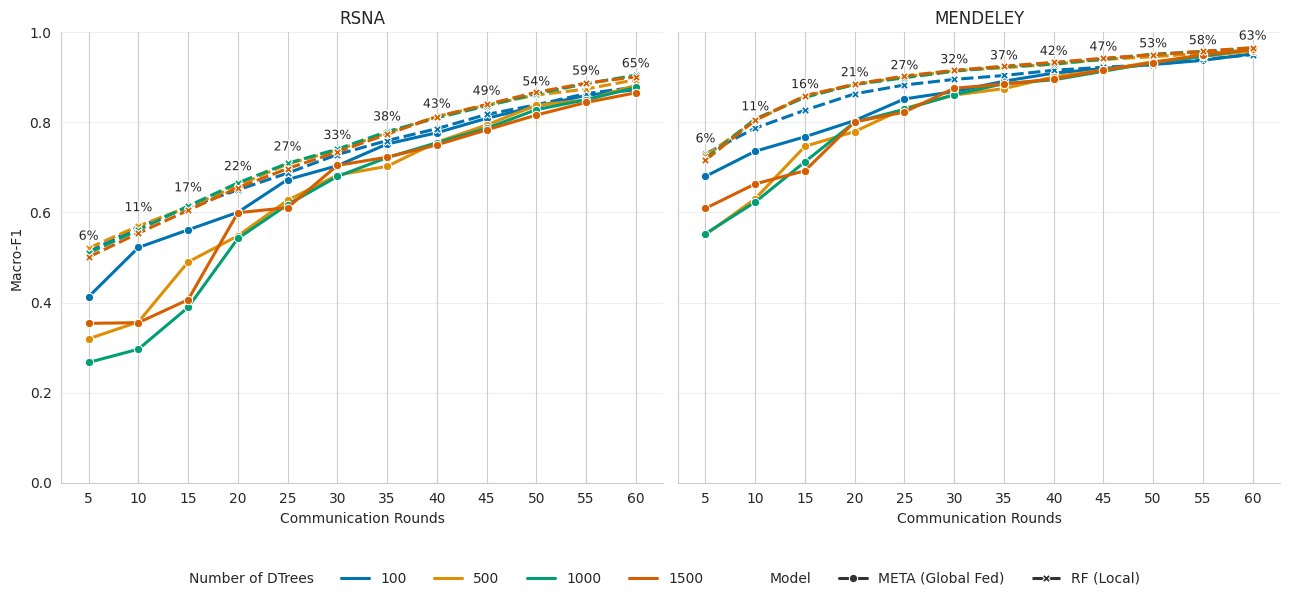

In [8]:
dfp = client_df_comm.copy()
dfp["round"] = dfp["round"].astype(int)
dfp["rf_n_estimators"] = dfp["rf_n_estimators"].astype(int)

# long format + rename legend fields
cols_keep = ["client","round","label %","rf_n_estimators"]
d_long = (
    dfp[cols_keep + ["meta_macro_f1","rf_macro_f1"]]
      .melt(id_vars=cols_keep, value_vars=["meta_macro_f1","rf_macro_f1"],
            var_name="Model", value_name="macro_f1")
      .replace({"Model": {"meta_macro_f1":"META (Global Fed)", "rf_macro_f1":"RF (Local)"}})
      .rename(columns={"rf_n_estimators":"Number of DTrees"})
)

sns.set_style("whitegrid")
palette = sns.color_palette("colorblind", d_long["Number of DTrees"].nunique())
clients = d_long["client"].unique().tolist()

fig, axes = plt.subplots(1, len(clients), figsize=(6*len(clients)+1, 6), sharey=True)
axes = np.atleast_1d(axes)

for ax, cl in zip(axes, clients):
    d = d_long[d_long["client"] == cl].copy().sort_values(["Number of DTrees","Model","round"])

    sns.lineplot(
        data=d, x="round", y="macro_f1",
        hue="Number of DTrees", style="Model",
        markers=True, dashes=True,
        linewidth=2.2, markersize=6,
        palette=palette, errorbar=None, ax=ax
    )

    # annotate once per round with label %
    for r, g in d.groupby("round"):
        pct = int(g["label %"].iloc[0])
        y_anchor = g["macro_f1"].max()
        txt = ax.text(r, y_anchor + 0.008, f"{pct}%",
                      ha="center", va="bottom", fontsize=9)
        txt.set_path_effects([pe.withStroke(linewidth=2, foreground="white")])

    rounds = sorted(d["round"].unique())
    ax.set_xticks(rounds)
    ax.set_ylim(0, 1)
    ax.set_title(cl)
    ax.set_xlabel("Communication Rounds")
    ax.set_ylabel("Macro-F1" if ax is axes[0] else "")
    ax.grid(True, axis="y", alpha=0.3)
    for sp in ["top","right"]:
        ax.spines[sp].set_visible(False)

    # hide per-axes legends
    lg = ax.get_legend()
    if lg is not None:
        lg.remove()

# one-row shared legend at the bottom, no title
handles, labels = axes[0].get_legend_handles_labels()
# de-duplicate while preserving order
seen = set(); H=[]; L=[]
for h,l in zip(handles, labels):
    if l not in seen:
        H.append(h); L.append(l); seen.add(l)

fig.legend(H, L, loc="lower center", ncol=len(L), frameon=False)  # one row, no title
plt.tight_layout(rect=(0,0.09,1,1))
plt.show()

fig.savefig("figures/effects_of_committee.png")

### Batch Size, lambda and seed method

In [69]:
folders = [os.path.join("runs/3_extras", dir_) for dir_ in os.listdir("runs/3_extras")]
run_data_frames = []
client_data_frames = []
for f in folders:
    run_df, client_df = run_folder_to_df_with_clients(f)
    run_data_frames.append(run_df)
    client_data_frames.append(client_df)

run_df_ex = pd.concat(run_data_frames, ignore_index=True)
client_df_ex = pd.concat(client_data_frames, ignore_index=True)

client_df_ex["label %"] = client_df_ex.apply(
    lambda r: int(100 * r["labels"] / (n_samples_rsna if r["client"] == "RSNA" else n_samples_mendeley)),
    axis=1
)
client_df_ex = client_df_ex[client_df_ex["round"] % 5 == 0]

In [70]:
client_df_ex.to_excel("results/batch_lamda_seed.xlsx")

In [13]:
client_df_lambda = client_df_ex[client_df_ex["run_id"].str.contains('lambda')]

In [14]:
client_df_lambda['batch_B']

8       100
9       100
18      100
19      100
28      100
       ... 
2499    100
2508    100
2509    100
2518    100
2519    100
Name: batch_B, Length: 336, dtype: int64

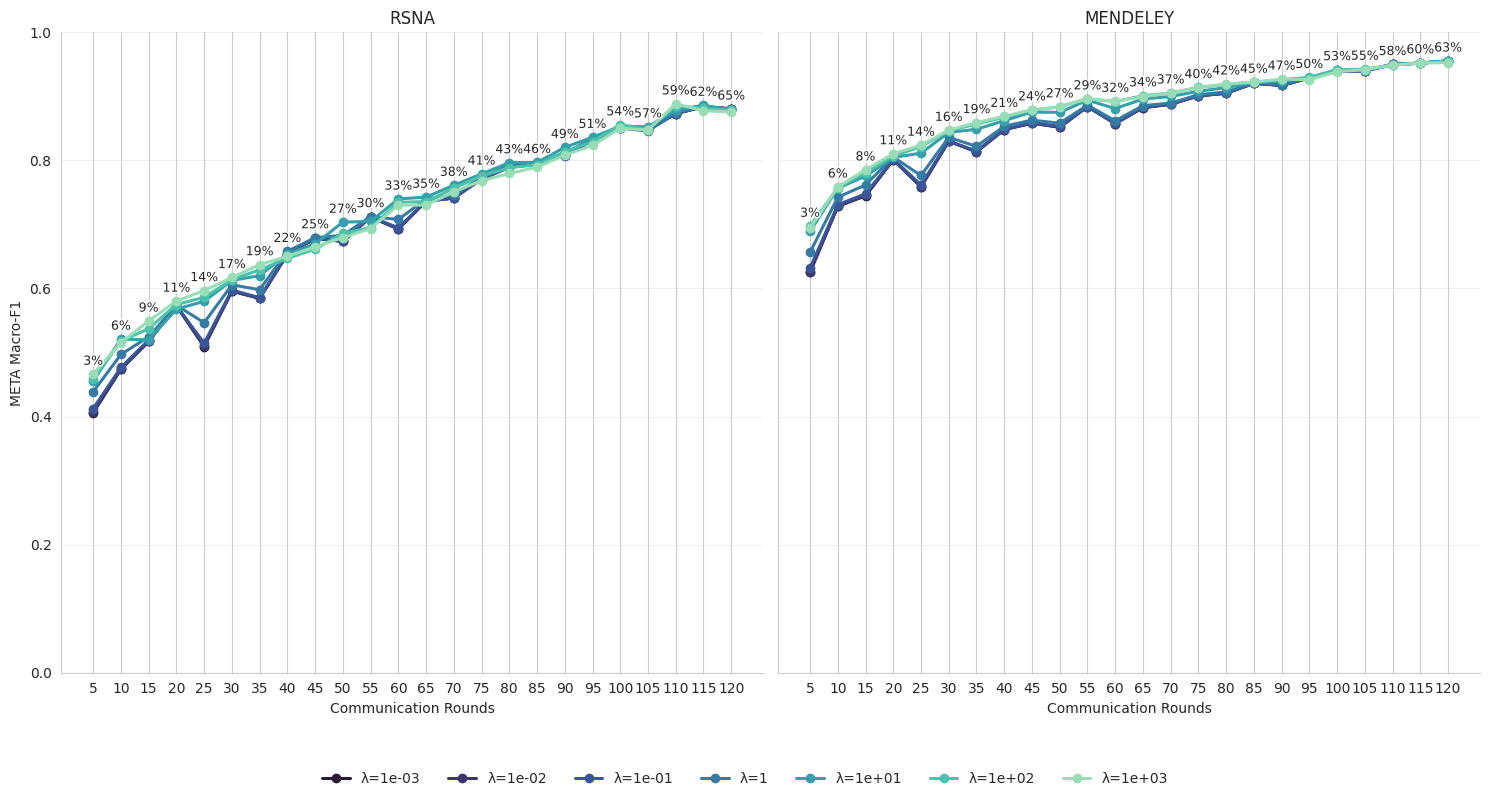

In [15]:
dfp = client_df_lambda.copy()

# (optional) keep a consistent K so λ effect isn’t confounded
if "aug_K" in dfp.columns:
    dfp = dfp[dfp["aug_K"].fillna(0).astype(int) == 0].copy()

dfp["round"] = dfp["round"].astype(int)
dfp["meta_lambda"] = pd.to_numeric(dfp["meta_lambda"], errors="coerce")

# pretty legend labels for lambda
def fmt_lam(x):
    x = float(x)
    return "1" if x == 1.0 else f"{x:.0e}"

dfp["Lambda"] = dfp["meta_lambda"].map(fmt_lam)

clients = dfp["client"].unique().tolist()
lam_levels = sorted(dfp["Lambda"].unique(), key=lambda s: float(s.replace("e","E")) if "e" in s.lower() else float(s))

sns.set_style("whitegrid")
palette = sns.color_palette("mako", len(lam_levels))

fig, axes = plt.subplots(1, len(clients), figsize=(6*len(clients)+3, 8), sharey=True)
axes = np.atleast_1d(axes)

for ax, cl in zip(axes, clients):
    d = dfp[dfp["client"] == cl].copy().sort_values(["Lambda","round"])

    # META curves by lambda (color)
    for color, lam in zip(palette, lam_levels):
        dm = d[d["Lambda"] == lam]
        if dm.empty:
            continue
        ax.plot(
            dm["round"], dm["meta_macro_f1"],
            linestyle="-", marker="o", color=color,
            linewidth=2.2, markersize=6, label=f"λ={lam}"
        )

    # annotate once per round with label %
    y_anchor = d.groupby("round", as_index=False)["meta_macro_f1"].max()
    pct_map = d.drop_duplicates(["round"]).set_index("round")["label %"].astype(int).to_dict()
    for r, y in zip(y_anchor["round"], y_anchor["meta_macro_f1"]):
        t = ax.text(r, y + 0.01, f"{pct_map.get(r, '')}%",
                    ha="center", va="bottom", fontsize=9)
        t.set_path_effects([pe.withStroke(linewidth=2, foreground="white")])

    rounds = sorted(d["round"].unique())
    ax.set_xticks(rounds)
    ax.set_ylim(0, 1)
    ax.set_title(cl)
    ax.set_xlabel("Communication Rounds")
    ax.set_ylabel("META Macro-F1" if ax is axes[0] else "")
    ax.grid(True, axis="y", alpha=0.3)
    for sp in ["top","right"]:
        ax.spines[sp].set_visible(False)

    # remove per-axes legends
    lg = ax.get_legend()
    if lg is not None:
        lg.remove()

# one-row shared legend at the bottom (no title)
from matplotlib.lines import Line2D
handles = [Line2D([0],[0], color=c, marker='o', linestyle='-', linewidth=2.2, markersize=6, label=f"λ={lam}")
           for c, lam in zip(palette, lam_levels)]
labels = [h.get_label() for h in handles]
fig.legend(handles, labels, loc="lower center", ncol=len(labels), frameon=False)

plt.tight_layout(rect=(0,0.08,1,1))
plt.show()

/tmp/ipykernel_3056863/1284170926.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = (dfλ.groupby(["Phase","Lambda"], as_index=False)["meta_macro_f1"].mean())


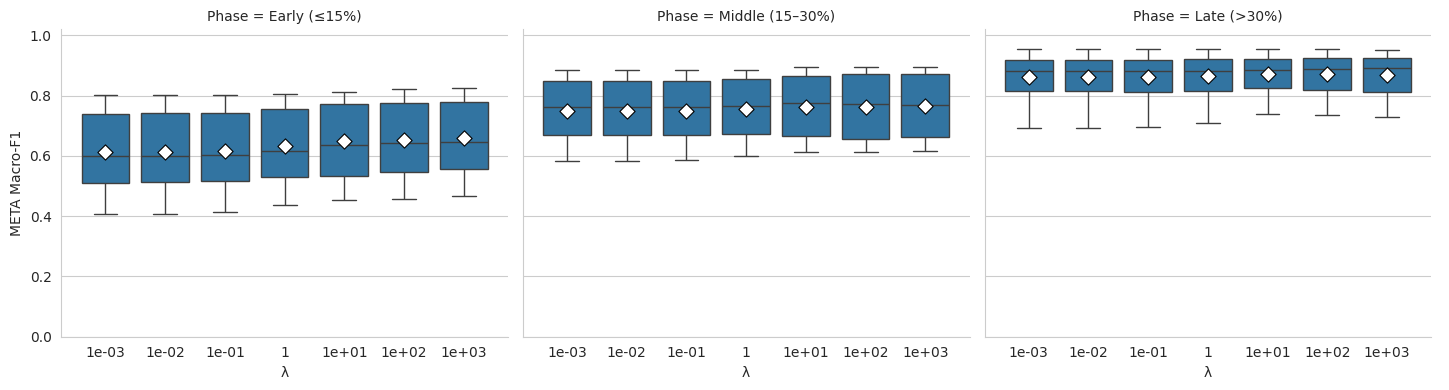

In [16]:
# --- starting from your lambda df ---
dfλ = client_df_lambda.copy()

# (optional) control for augmentation if needed
# dfλ = dfλ[dfλ["aug_K"].fillna(0).astype(int) == 0]

# tidy types
dfλ["round"] = dfλ["round"].astype(int)
dfλ["label %"] = pd.to_numeric(dfλ["label %"], errors="coerce")
dfλ["meta_lambda"] = pd.to_numeric(dfλ["meta_lambda"], errors="coerce")

# pretty lambda labels
def fmt_lam(x):
    try: x = float(x)
    except: return str(x)
    return "1" if x == 1.0 else f"{x:.0e}"

dfλ["Lambda"] = dfλ["meta_lambda"].map(fmt_lam)

# phase buckets (no client facet)
bins   = [-np.inf, 15, 30, np.inf]
ph_lbl = ["Early (≤15%)", "Middle (15–30%)", "Late (>30%)"]
dfλ["Phase"] = pd.cut(dfλ["label %"], bins=bins, labels=ph_lbl, right=True, include_lowest=True)

# canonical orders
lam_order   = sorted(dfλ["Lambda"].dropna().unique(), key=lambda s: float(s.replace("e","E")) if "e" in s.lower() else float(s))
phase_order = ph_lbl

sns.set_style("whitegrid")

# --- boxplots per phase (columns), no clients ---
g = sns.catplot(
    data=dfλ, x="Lambda", y="meta_macro_f1",
    col="Phase", col_order=phase_order,
    order=lam_order, kind="box",
    height=4.0, aspect=1.2, showfliers=False
)

# overlay MEAN diamonds (Matplotlib scatter → no seaborn deprecations)
means = (dfλ.groupby(["Phase","Lambda"], as_index=False)["meta_macro_f1"].mean())
axes = g.axes.flatten()

for ax, ph in zip(axes, phase_order):
    sub = means[means["Phase"] == ph]
    x_pos = [lam_order.index(x) for x in sub["Lambda"]]
    ax.scatter(x_pos, sub["meta_macro_f1"],
               marker="D", s=60, linewidths=0.8,
               edgecolors="black", color="white", zorder=3)

    ax.set_xlabel("λ")
    ax.set_ylabel("META Macro-F1")
    ax.set_ylim(0.0, 1.02)
    ax.set_xticks(range(len(lam_order)))
    ax.set_xticklabels(lam_order, rotation=0)
    for sp in ["top","right"]:
        ax.spines[sp].set_visible(False)

plt.tight_layout()
plt.show()

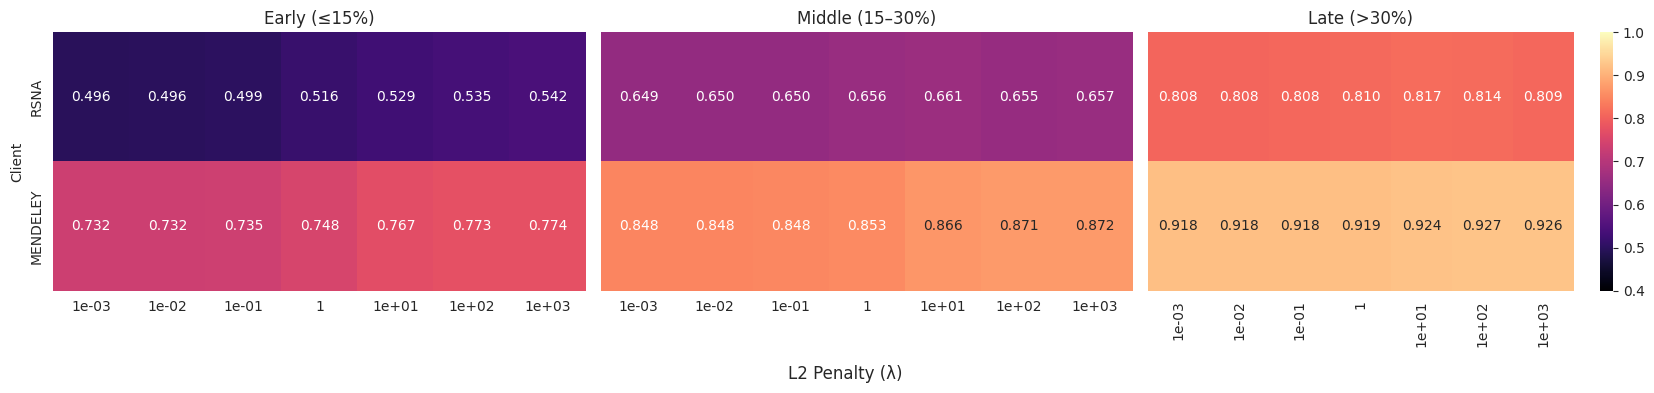

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4), sharey=True)
for ax, ph in zip(axes, phase_order):
    pivot = (dfλ[dfλ["Phase"] == ph]
             .groupby(["client", "Lambda"])["meta_macro_f1"]
             .mean()
             .unstack("Lambda")
             .reindex(index=clients, columns=lam_order))

    sns.heatmap(pivot, annot=True, fmt=".3f",
                cmap="magma", vmin=0.4, vmax=1.0,
                cbar=(ax is axes[-1]), ax=ax)
    ax.set_title(ph)
    ax.set_xlabel("")
    ax.set_ylabel("Client" if ax is axes[0] else "")

fig.supxlabel("L2 Penalty (λ)", y=0.03)
plt.tight_layout()
plt.show()
fig.savefig('figures/effect_of_lambda.png')

### Effect of Augmentation and AL methods

In [73]:
folders = [os.path.join("runs/4_sampler_aug", dir_) for dir_ in os.listdir("runs/4_sampler_aug")]
run_data_frames = []
client_data_frames = []
for f in folders:
    run_df, client_df = run_folder_to_df_with_clients(f)
    run_data_frames.append(run_df)
    client_data_frames.append(client_df)

run_df_sampler = pd.concat(run_data_frames, ignore_index=True)
client_df_sampler = pd.concat(client_data_frames, ignore_index=True)

client_df_sampler["label %"] = client_df_sampler.apply(
    lambda r: int(100 * r["labels"] / (n_samples_rsna if r["client"] == "RSNA" else n_samples_mendeley)),
    axis=1
)

# client_df_sampler = client_df_sampler[client_df_sampler["round"] % 5 == 0]

In [72]:
client_df_sampler.to_excel("results/effect_of_augmentation.xlsx")

In [21]:
client_df_al = client_df_sampler[client_df_sampler["aug_K"] == 0]
client_df_al

,round,labels,client,rf_macro_f1,meta_macro_f1,rf_bal_acc,meta_bal_acc,rf_auc_ovr,meta_auc_ovr,picked_per_class,...,aug_K,meta_mode,tta_n,meta_lambda,rf_n_estimators,rf_max_features,seeding_method,run_id,path,label %
1328,5,1200,RSNA,0.520299,0.434896,0.525522,0.434048,0.817486,0.802104,"{'L1/L2': 45, 'L3/L4': 40, 'L4/L5': 51, 'L2/L3...",...,0,off,0,1e-2,100,sqrt,k_coreset,study4_entropy_K0_off_seed200_B200_R60,runs/4_sampler_aug/study4_entropy_K0_off_seed2...,6
1329,5,1200,MENDELEY,0.741044,0.698526,0.731926,0.672476,0.923171,0.919381,"{'L3/L4': 46, 'L4/L5': 53, 'L5/S1': 37, 'L2/L3...",...,0,off,0,1e-2,100,sqrt,k_coreset,study4_entropy_K0_off_seed200_B200_R60,runs/4_sampler_aug/study4_entropy_K0_off_seed2...,6
1338,10,2200,RSNA,0.566142,0.532352,0.571660,0.553135,0.850275,0.831558,"{'L3/L4': 21, 'L5/S1': 42, 'L4/L5': 53, 'L2/L3...",...,0,off,0,1e-2,100,sqrt,k_coreset,study4_entropy_K0_off_seed200_B200_R60,runs/4_sampler_aug/study4_entropy_K0_off_seed2...,11
1339,10,2200,MENDELEY,0.797540,0.725223,0.793471,0.728440,0.945383,0.935281,"{'L5/S1': 34, 'L2/L3': 38, 'L3/L4': 67, 'L4/L5...",...,0,off,0,1e-2,100,sqrt,k_coreset,study4_entropy_K0_off_seed200_B200_R60,runs/4_sampler_aug/study4_entropy_K0_off_seed2...,11
1348,15,3200,RSNA,0.606663,0.592708,0.616439,0.583910,0.877478,0.871470,"{'L2/L3': 41, 'L4/L5': 57, 'L5/S1': 28, 'L1/L2...",...,0,off,0,1e-2,100,sqrt,k_coreset,study4_entropy_K0_off_seed200_B200_R60,runs/4_sampler_aug/study4_entropy_K0_off_seed2...,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7373,50,10200,MENDELEY,0.946370,0.935745,0.941793,0.930148,0.992231,0.991924,"{'L5/S1': 39, 'L4/L5': 70, 'L3/L4': 68, 'L2/L3...",...,0,off,0,1e-2,100,sqrt,k_coreset,study4_qbc_K0_off_seed200_B200_R60,runs/4_sampler_aug/study4_qbc_K0_off_seed200_B...,53
7382,55,11200,RSNA,0.863805,0.866453,0.858404,0.863225,0.981401,0.980715,"{'L1/L2': 29, 'L2/L3': 48, 'L4/L5': 40, 'L3/L4...",...,0,off,0,1e-2,100,sqrt,k_coreset,study4_qbc_K0_off_seed200_B200_R60,runs/4_sampler_aug/study4_qbc_K0_off_seed200_B...,59
7383,55,11200,MENDELEY,0.956053,0.953947,0.951553,0.951228,0.993229,0.993553,"{'L3/L4': 68, 'L5/S1': 43, 'L4/L5': 71, 'L2/L3...",...,0,off,0,1e-2,100,sqrt,k_coreset,study4_qbc_K0_off_seed200_B200_R60,runs/4_sampler_aug/study4_qbc_K0_off_seed200_B...,58
7392,60,12200,RSNA,0.880615,0.880875,0.861015,0.871075,0.985531,0.982754,"{'L2/L3': 38, 'L4/L5': 32, 'L1/L2': 38, 'L3/L4...",...,0,off,0,1e-2,100,sqrt,k_coreset,study4_qbc_K0_off_seed200_B200_R60,runs/4_sampler_aug/study4_qbc_K0_off_seed200_B...,65


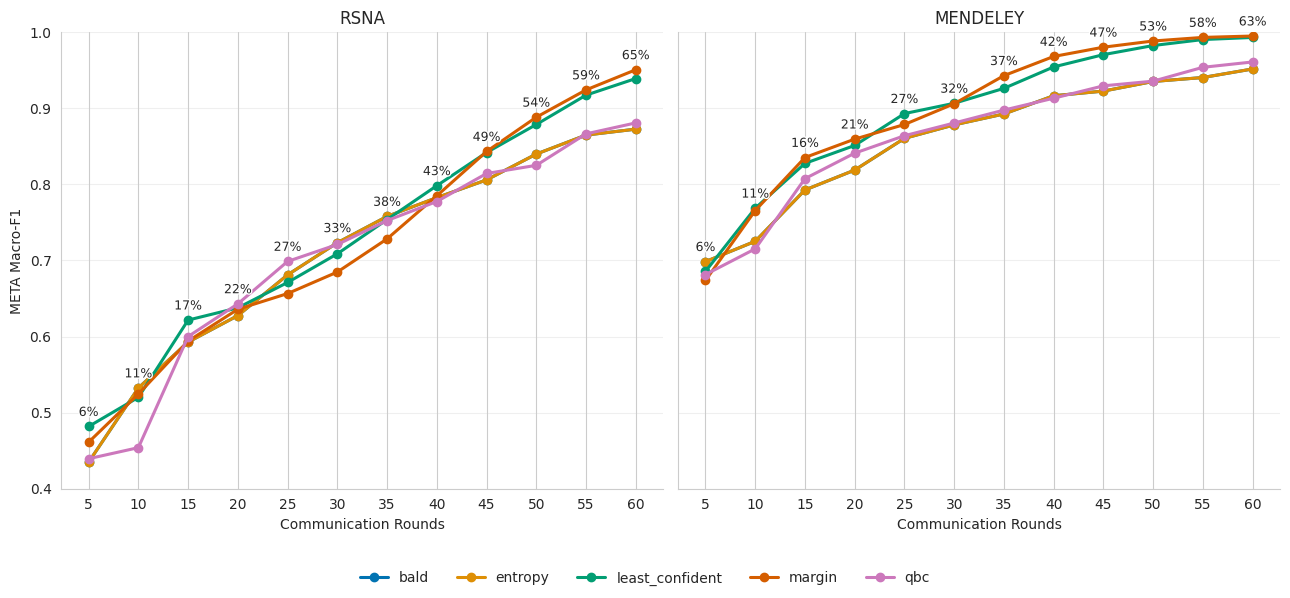

In [24]:
# --- prep ---
dfp = client_df_al.copy()

# be robust to column naming
if "al_method_cfg" in dfp.columns:
    dfp = dfp.rename(columns={"al_method_cfg": "AL Method"})
elif "al_method" in dfp.columns:
    dfp = dfp.rename(columns={"al_method": "AL Method"})
else:
    raise KeyError("Expected 'al_method_cfg' or 'al_method' in client_df_al")

# (optional) control for other factors if present to isolate AL effect
# dfp = dfp[dfp["aug_K"].fillna(0).astype(int) == 0]         # e.g., no aug
# dfp = dfp[dfp["tta_n"].fillna(0).astype(int) == 0]         # e.g., TTA off

dfp["round"] = dfp["round"].astype(int)
if "label %" in dfp.columns:
    dfp["label %"] = pd.to_numeric(dfp["label %"], errors="coerce").astype(int)

clients = dfp["client"].unique().tolist()
al_order = sorted(dfp["AL Method"].unique().tolist())

sns.set_style("whitegrid")
palette = sns.color_palette("colorblind", len(al_order))

fig, axes = plt.subplots(1, len(clients), figsize=(6*len(clients)+1, 6), sharey=True)
axes = np.atleast_1d(axes)

for ax, cl in zip(axes, clients):
    d = dfp[dfp["client"] == cl].copy().sort_values(["AL Method","round"])

    # draw lines: color = AL method
    for color, m in zip(palette, al_order):
        dm = d[d["AL Method"] == m]
        if dm.empty:
            continue
        ax.plot(
            dm["round"], dm["meta_macro_f1"],
            marker="o", linestyle="-", linewidth=2.2, markersize=6,
            color=color, label=m
        )

    # annotate once per round with label %
    if "label %" in d.columns:
        y_anchor = d.groupby("round", as_index=False)["meta_macro_f1"].max()
        pct_map = d.drop_duplicates(["round"]).set_index("round")["label %"].to_dict()
        for r, y in zip(y_anchor["round"], y_anchor["meta_macro_f1"]):
            t = ax.text(r, y + 0.01, f"{pct_map.get(r, '')}%",
                        ha="center", va="bottom", fontsize=9)
            t.set_path_effects([pe.withStroke(linewidth=2, foreground="white")])

    # axes polish
    rounds = sorted(d["round"].unique())
    ax.set_xticks(rounds)
    ax.set_ylim(0.4,1)
    ax.set_title(cl)
    ax.set_xlabel("Communication Rounds")
    ax.set_ylabel("META Macro-F1" if ax is axes[0] else "")
    ax.grid(True, axis="y", alpha=0.3)
    for sp in ["top","right"]:
        ax.spines[sp].set_visible(False)

    # remove per-axes legends; we'll add a shared one
    lg = ax.get_legend()
    if lg is not None:
        lg.remove()

# shared bottom legend (one row, no title)
from matplotlib.lines import Line2D
handles = [Line2D([0],[0], color=c, marker='o', linestyle='-', linewidth=2.2, markersize=6, label=m)
           for c, m in zip(palette, al_order)]
labels = [h.get_label() for h in handles]
fig.legend(handles, labels, loc="lower center", ncol=len(labels), frameon=False)

plt.tight_layout(rect=(0,0.08,1,1))
plt.show()

fig.savefig("figures/effects_of_AL.png")

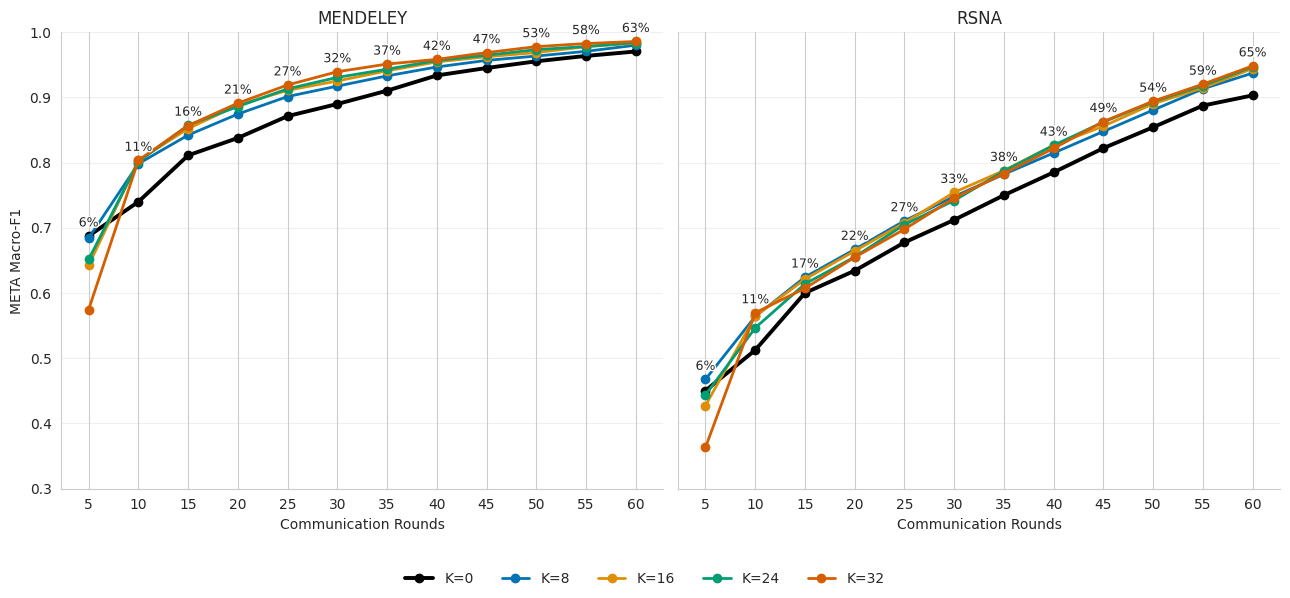

In [35]:
# ----- prep -----
dfp = client_df_sampler[(client_df_sampler["tta_n"] == 0)]
dfp = dfp[['client', 'round',  'aug_K', 'label %', 'meta_macro_f1']].groupby(["client", "label %", "aug_K"], as_index=False).mean()
# # (optional) isolate a single AL method / TTA setting so K effect isn't confounded
# # dfp = dfp[dfp["al_method_cfg"] == "qbc"]
# # dfp = dfp[dfp["meta_mode"].astype(str).str.lower() == "off"]
# # dfp = dfp[dfp["tta_n"].fillna(0).astype(int) == 0]

# # ----- prep -----
# dfp = client_df_sampler.copy()

# (optional) isolate a single AL method / TTA setting so K effect isn't confounded
# dfp = dfp[dfp["al_method_cfg"] == "qbc"]
# dfp = dfp[dfp["meta_mode"].astype(str).str.lower() == "off"]
# dfp = dfp[dfp["tta_n"].fillna(0).astype(int) == 0]

dfp["round"]  = pd.to_numeric(dfp["round"], errors="coerce").astype(int)
dfp["aug_K"]  = pd.to_numeric(dfp["aug_K"], errors="coerce").fillna(0).astype(int)
if "label %" in dfp.columns:
    dfp["label %"] = pd.to_numeric(dfp["label %"], errors="coerce").astype(int)

clients = dfp["client"].unique().tolist()
K_vals  = sorted(dfp["aug_K"].unique())
K_cols  = [k for k in K_vals if k != 0]  # non-baseline

sns.set_style("whitegrid")
palette = sns.color_palette("colorblind", len(K_cols))

fig, axes = plt.subplots(1, len(clients), figsize=(6*len(clients)+1, 6), sharey=True)
axes = np.atleast_1d(axes)

for ax, cl in zip(axes, clients):
    d = dfp[dfp["client"] == cl].copy().sort_values(["aug_K","round"])

    # --- baseline K=0 (black, thicker) ---
    d0 = d[d["aug_K"] == 0]
    if not d0.empty:
        ax.plot(
            d0["round"], d0["meta_macro_f1"],
            color="black", linewidth=2.8, marker="o", markersize=6,
            linestyle="-", label="K=0"
        )

    # --- other K values (colored) ---
    for color, k in zip(palette, K_cols):
        dk = d[d["aug_K"] == k]
        if dk.empty:
            continue
        ax.plot(
            dk["round"], dk["meta_macro_f1"],
            color=color, linewidth=2.0, marker="o", markersize=6,
            linestyle="-", label=f"K={k}"
        )

    # --- annotate once per round with label % (above highest curve at that round) ---
    if "label %" in d.columns and not d.empty:
        y_anchor = d.groupby("round", as_index=False)["meta_macro_f1"].max()
        pct_map  = d.drop_duplicates(["round"]).set_index("round")["label %"].to_dict()
        for r, y in zip(y_anchor["round"], y_anchor["meta_macro_f1"]):
            t = ax.text(r, y + 0.01, f"{pct_map.get(r, '')}%",
                        ha="center", va="bottom", fontsize=9)
            t.set_path_effects([pe.withStroke(linewidth=2, foreground="white")])

    # --- axes polish ---
    rounds = sorted(d["round"].unique())
    if rounds:
        ax.set_xticks(rounds)
    ax.set_ylim(0.3, 1)
    ax.set_title(cl)
    ax.set_xlabel("Communication Rounds")
    ax.set_ylabel("META Macro-F1" if ax is axes[0] else "")
    ax.grid(True, axis="y", alpha=0.3)
    for sp in ["top","right"]:
        ax.spines[sp].set_visible(False)

    # remove per-axes legends
    lg = ax.get_legend()
    if lg is not None:
        lg.remove()

# --- shared bottom legend (one row, no title) ---
from matplotlib.lines import Line2D
handles = [Line2D([0],[0], color="black", marker="o", linestyle="-", linewidth=2.8, markersize=6, label="K=0")] + \
          [Line2D([0],[0], color=c, marker="o", linestyle="-", linewidth=2.0, markersize=6, label=f"K={k}")
           for c, k in zip(palette, K_cols)]
labels = [h.get_label() for h in handles]
fig.legend(handles, labels, loc="lower center", ncol=len(labels), frameon=False)

plt.tight_layout(rect=(0,0.08,1,1))
plt.show()
fig.savefig("figures/effect_of_aug_line.png")

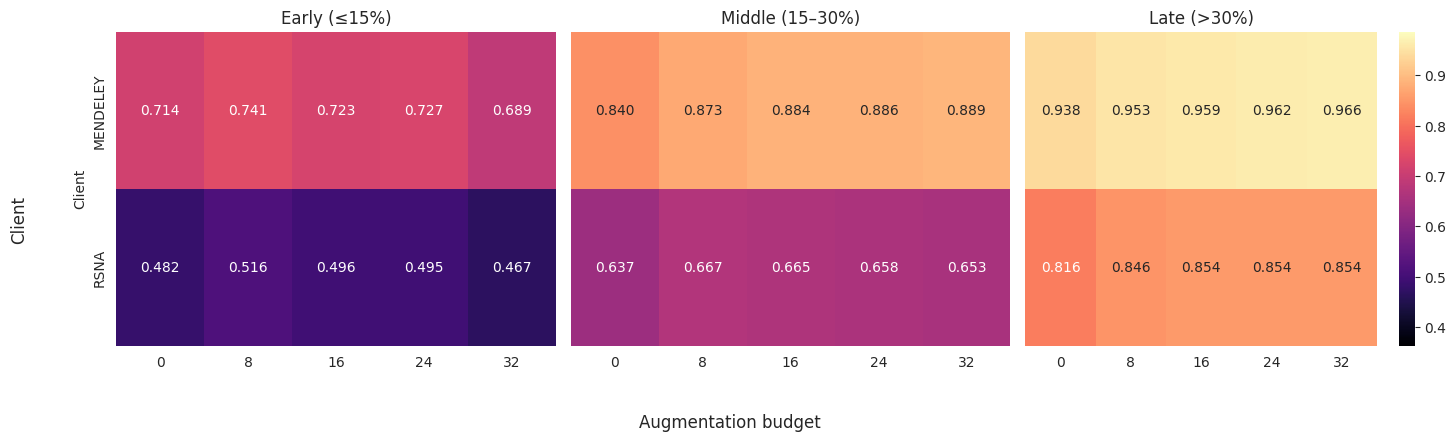

In [36]:
# =========================
# 1) PREP
# =========================
d = client_df_sampler.copy()
d = d[d["tta_n"].fillna(0).astype(int) == 0]

d = (d[["client", "label %", "aug_K", "meta_macro_f1"]]
     .groupby(["client", "label %", "aug_K"], as_index=False)["meta_macro_f1"]
     .mean())

d["aug_K"]   = pd.to_numeric(d["aug_K"], errors="coerce").fillna(0).astype(int)
d["label %"] = pd.to_numeric(d["label %"], errors="coerce")

client_order = sorted(d["client"].unique().tolist())
K_order      = sorted(d["aug_K"].unique().tolist())

# =========================
# 2) PHASES by label %
# =========================
def pct_to_phase(p):
    if pd.isna(p):
        return np.nan
    if p <= 15:
        return "Early (≤15%)"
    elif p <= 30:
        return "Middle (15–30%)"
    else:
        return "Late (>30%)"

d["Phase"] = d["label %"].apply(pct_to_phase)
phase_order = ["Early (≤15%)", "Middle (15–30%)", "Late (>30%)"]

# =========================
# 3) HEATMAPS + common X label
# =========================
sns.set_style("white")
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

vmin = float(d["meta_macro_f1"].min())
vmax = float(d["meta_macro_f1"].max())

for ax, ph in zip(axes, phase_order):
    pivot = (d[d["Phase"] == ph]
             .groupby(["client", "aug_K"])["meta_macro_f1"]
             .mean()
             .unstack("aug_K")
             .reindex(index=client_order, columns=K_order))

    sns.heatmap(
        pivot, annot=True, fmt=".3f",
        cmap="magma", vmin=vmin, vmax=vmax,
        cbar=(ax is axes[-1]),
        ax=ax
    )
    ax.set_title(ph)
    ax.set_xlabel("")  # remove per-panel x label
    ax.set_ylabel("Client" if ax is axes[0] else "")

# Common labels
fig.supxlabel("Augmentation budget", y=0.03)
fig.supylabel("Client")

plt.tight_layout(rect=(0.03, 0.06, 1, 1))
plt.show()

fig.savefig("figures/effect_of_aug_heatmap.png")

In [28]:
cut2

45

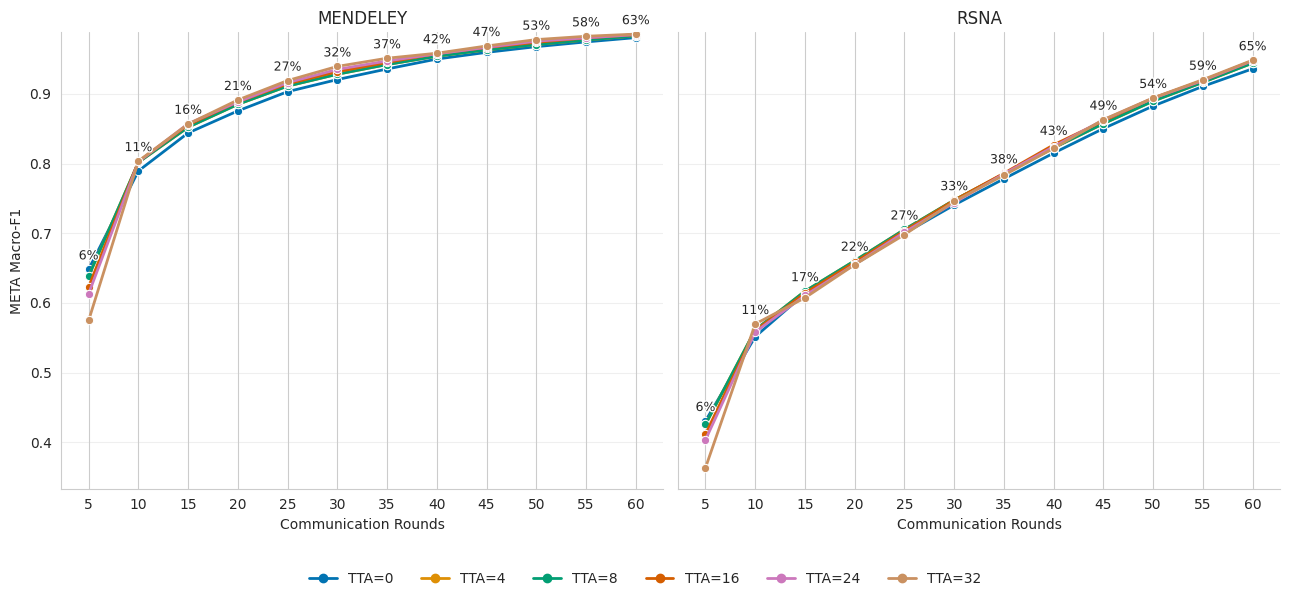

In [85]:
df_round = (
    client_df_sampler[["client","round","tta_n","label %","meta_macro_f1"]]
      .dropna(subset=["round","tta_n","meta_macro_f1"])
      .copy()
)

df_round["round"]   = pd.to_numeric(df_round["round"], errors="coerce").astype(int)
df_round["tta_n"]   = pd.to_numeric(df_round["tta_n"], errors="coerce").fillna(0).astype(int)
df_round["label %"] = pd.to_numeric(df_round["label %"], errors="coerce").round(0).astype(int)

# average across replicates within client×round×tta_n (if any)
df_round = (df_round
            .groupby(["client","round","tta_n"], as_index=False)
            .agg({"meta_macro_f1":"mean", "label %":"median"}))

# --- plot: x = rounds, hue = tta_n, facet by client, annotate label % ---
sns.set_style("whitegrid")
clients    = df_round["client"].unique().tolist()
tta_levels = sorted(df_round["tta_n"].unique())
palette    = sns.color_palette("colorblind", len(tta_levels))

fig, axes = plt.subplots(1, len(clients), figsize=(6*len(clients)+1, 6), sharey=True)
axes = np.atleast_1d(axes)

for ax, cl in zip(axes, clients):
    d = df_round[df_round["client"] == cl].sort_values(["tta_n","round"])

    # lines per tta_n
    sns.lineplot(
        data=d, x="round", y="meta_macro_f1",
        hue="tta_n", hue_order=tta_levels,
        palette=palette, marker="o", dashes=False,
        linewidth=2.0, markersize=6, errorbar=None, ax=ax
    )

    # annotate once per round with label % (above the highest curve at that round)
    y_anchor = d.groupby("round", as_index=False)["meta_macro_f1"].max()
    pct_map  = d.groupby("round", as_index=True)["label %"].median().astype(int).to_dict()
    for r, y in zip(y_anchor["round"], y_anchor["meta_macro_f1"]):
        txt = ax.text(r, y + 0.01, f"{pct_map.get(r,'')}%",
                      ha="center", va="bottom", fontsize=9)
        txt.set_path_effects([pe.withStroke(linewidth=2, foreground="white")])

    # axes polish
    rounds = sorted(d["round"].unique())
    if rounds:
        ax.set_xticks(rounds)
    ax.set_ylim(max(0.0, d["meta_macro_f1"].min()-0.03),
                min(1.0, d["meta_macro_f1"].max()+0.04))
    ax.set_title(cl)
    ax.set_xlabel("Communication Rounds")
    ax.set_ylabel("META Macro-F1" if ax is axes[0] else "")
    ax.grid(True, axis="y", alpha=0.3)
    for sp in ["top","right"]:
        ax.spines[sp].set_visible(False)

    # remove per-axes legends; we'll add a shared one
    lg = ax.get_legend()
    if lg is not None:
        lg.remove()

# shared bottom legend (one row, no title)
handles = [Line2D([0],[0], color=c, marker='o', linestyle='-',
                  linewidth=2.0, markersize=6, label=f"TTA={t}")
           for c, t in zip(palette, tta_levels)]
fig.legend(handles, [h.get_label() for h in handles],
           loc="lower center", ncol=len(handles), frameon=False)

plt.tight_layout(rect=(0,0.08,1,1))
plt.show()

### FedMeta vs FedAvg, FedProx, FedNova 

In [45]:
client_df_al

,round,labels,client,rf_macro_f1,meta_macro_f1,rf_bal_acc,meta_bal_acc,rf_auc_ovr,meta_auc_ovr,picked_per_class,...,aug_K,meta_mode,tta_n,meta_lambda,rf_n_estimators,rf_max_features,seeding_method,run_id,path,label %
1438,60,12200,RSNA,0.879212,0.872649,0.863714,0.865357,0.985719,0.982931,"{'L1/L2': 46, 'L5/S1': 62, 'L4/L5': 33, 'L2/L3...",...,0,off,0,1e-2,100,sqrt,k_coreset,study4_entropy_K0_off_seed200_B200_R60,runs/4_sampler_aug/study4_entropy_K0_off_seed2...,65
1918,60,12200,RSNA,0.879212,0.872649,0.863714,0.865357,0.985719,0.982931,"{'L1/L2': 46, 'L5/S1': 62, 'L4/L5': 33, 'L2/L3...",...,0,off,0,1e-2,100,sqrt,k_coreset,study4_bald_K0_off_seed200_B200_R60,runs/4_sampler_aug/study4_bald_K0_off_seed200_...,65
3238,60,12200,RSNA,0.950755,0.950755,0.942700,0.942700,0.987976,0.985263,"{'L5/S1': 66, 'L1/L2': 49, 'L4/L5': 30, 'L2/L3...",...,0,off,0,1e-2,100,sqrt,k_coreset,study4_margin_K0_off_seed200_B200_R60,runs/4_sampler_aug/study4_margin_K0_off_seed20...,65
4198,60,12200,RSNA,0.939181,0.939181,0.926986,0.926986,0.987204,0.986981,"{'L2/L3': 36, 'L5/S1': 58, 'L4/L5': 35, 'L1/L2...",...,0,off,0,1e-2,100,sqrt,k_coreset,study4_least_confident_K0_off_seed200_B200_R60,runs/4_sampler_aug/study4_least_confident_K0_o...,65
7392,60,12200,RSNA,0.880615,0.880875,0.861015,0.871075,0.985531,0.982754,"{'L2/L3': 38, 'L4/L5': 32, 'L1/L2': 38, 'L3/L4...",...,0,off,0,1e-2,100,sqrt,k_coreset,study4_qbc_K0_off_seed200_B200_R60,runs/4_sampler_aug/study4_qbc_K0_off_seed200_B...,65


In [74]:
client_df_al = client_df_sampler[client_df_sampler["aug_K"] == 0]

df_fedrest = pd.read_csv("fed_results.csv", index_col=0)

client_df_al = client_df_al[client_df_al['label %'].isin(df_fedrest['label %'].unique())]

df_fedmeta = client_df_al[['client', 'round', 'label %', 'meta_macro_f1']].groupby(['client', 'round', 'label %'], as_index = False).mean()

df_fedrest

,client,fl_method,round,label %,meta_macro_f1,bal_acc,acc
0,MENDELEY,fedavg,4,5,0.112008,0.212349,0.302902
1,MENDELEY,fedavg,9,10,0.271278,0.315644,0.408837
2,MENDELEY,fedavg,18,20,0.380812,0.403547,0.491885
3,MENDELEY,fedavg,23,25,0.440070,0.446340,0.525506
4,MENDELEY,fedavg,32,35,0.548519,0.531669,0.593323
5,MENDELEY,fedavg,37,40,0.607672,0.576488,0.637738
6,MENDELEY,fedavg,46,50,0.669045,0.632845,0.697004
7,MENDELEY,fedavg,51,55,0.700063,0.665387,0.725239
8,MENDELEY,fedavg,60,65,0.734532,0.694717,0.771647
9,MENDELEY,fednova,4,5,0.121136,0.219344,0.312546


In [77]:
df_all.to_excel("results/comparisons.xlsx")

In [76]:
df_fedmeta

,client,round,label %,meta_macro_f1
0,MENDELEY,4,5,0.644375
1,MENDELEY,9,10,0.746598
2,MENDELEY,19,20,0.835915
3,MENDELEY,33,35,0.898367
4,MENDELEY,38,40,0.924241
5,MENDELEY,48,50,0.953159
6,MENDELEY,52,55,0.958835
7,RSNA,4,5,0.446068
8,RSNA,9,10,0.508179
9,RSNA,18,20,0.605628


<Figure size 1600x700 with 0 Axes>

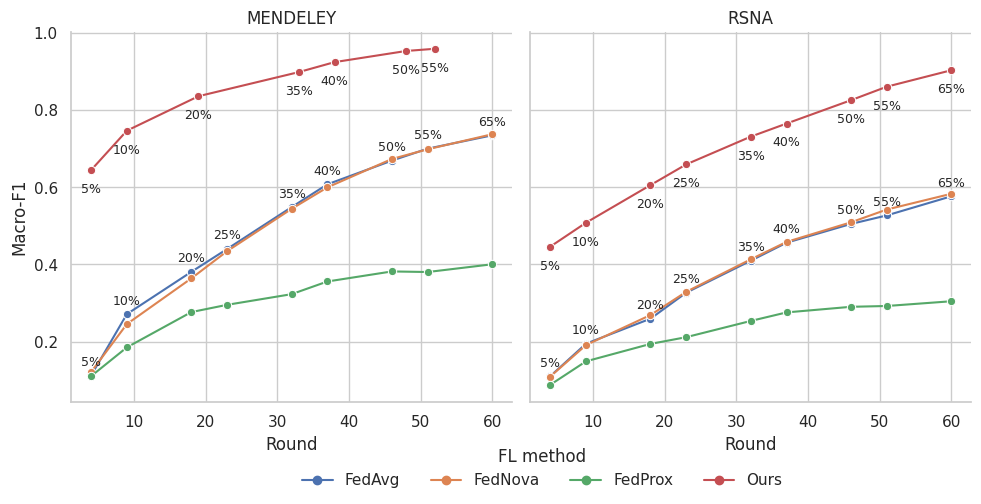

In [57]:
# --- prepare data ---

df_fedmeta_plot = df_fedmeta.copy()
df_fedmeta_plot["fl_method"] = "fedmeta"   # name used in legend
# keep label % so we can annotate
df_fedmeta_plot = df_fedmeta_plot[["client", "round", "label %", "meta_macro_f1", "fl_method"]]

df_fedrest_plot = df_fedrest[["client", "round", "label %", "meta_macro_f1", "fl_method"]].copy()

df_all = pd.concat([df_fedrest_plot, df_fedmeta_plot], ignore_index=True)

plt.figure(figsize=(16, 7))

sns.set(style="whitegrid")

hue_order = ["fedavg", "fednova", "fedprox", "fedmeta"]

g = sns.relplot(
    data=df_all,
    x="round",
    y="meta_macro_f1",
    hue="fl_method",
    hue_order=hue_order,
    col="client",
    kind="line",
    marker="o",
    facet_kws={"sharex": True, "sharey": True}
)

# axis labels
g.set_axis_labels("Round", "Macro-F1")

# remove "client =" in titles
g.set_titles("{col_name}")

# --- move legend to bottom and rename entries ---

# grab handles/labels from one of the axes
handles, labels = g.axes[0][0].get_legend_handles_labels()

label_map = {
    "fedavg": "FedAvg",
    "fednova": "FedNova",
    "fedprox": "FedProx",
    "fedmeta": "Ours",
}
new_labels = [label_map.get(l, l) for l in labels]

# remove per-axes legend
if g._legend is not None:
    g._legend.remove()

# global legend at bottom
g.fig.legend(
    handles,
    new_labels,
    title="FL method",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=4,
    frameon=False,
)

plt.subplots_adjust(bottom=0.18)  # make room for legend

# --- annotate fedavg and fedmeta lines with label % ---

for client_name, ax in g.axes_dict.items():
    sub = df_all[df_all["client"] == client_name]

    # annotate FedAvg
    sub_avg = sub[sub["fl_method"] == "fedavg"]
    for _, row in sub_avg.iterrows():
        ax.annotate(
            f"{int(row['label %'])}%",
            xy=(row["round"], row["meta_macro_f1"]),
            xytext=(0, 5),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    # annotate FedMeta
    sub_meta = sub[sub["fl_method"] == "fedmeta"]
    for _, row in sub_meta.iterrows():
        ax.annotate(
            f"{int(row['label %'])}%",
            xy=(row["round"], row["meta_macro_f1"]),
            xytext=(0, -9),  # offset a bit above to avoid overlap
            textcoords="offset points",
            ha="center",
            va="top",
            fontsize=9,
        )

plt.show()
g.fig.savefig('figures/comparison.png')

In [78]:
df_all

,client,round,label %,meta_macro_f1,fl_method
0,MENDELEY,4,5,0.112008,fedavg
1,MENDELEY,9,10,0.271278,fedavg
2,MENDELEY,18,20,0.380812,fedavg
3,MENDELEY,23,25,0.440070,fedavg
4,MENDELEY,32,35,0.548519,fedavg
...,...,...,...,...,...
65,RSNA,32,35,0.731163,fedmeta
66,RSNA,37,40,0.765102,fedmeta
67,RSNA,46,50,0.825624,fedmeta
68,RSNA,51,55,0.860650,fedmeta
